<a href="https://colab.research.google.com/github/vkatsel/app-analysis/blob/main/Subscription_App_Unit_Economics_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Аналіз юніт-економіки додатку для вивчення мов




## Підготовка даних до аналізу

> ⚠️ Для зручності та правильної роботи - рекомендовано виконати всі клітинки послідовно. Скористайтеся кнопкою "Виконати всі" у верхньому меню

> ⚠️ Для коректного відпрацювання коду, завантажте датасет для тестового завдання при виконанні першої клітинки


In [65]:
from google.colab import drive, files
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from IPython.display import IFrame

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name="Payments_data")
df.head()

Saving data.xlsx to data (1).xlsx


,Unnamed: 0,rc_original_app_user_id,country,product_identifier,product_duration,start_time,end_time,is_trial_period,is_sandbox,refunded_at,renewal_number,tax_percentage,commission_percentage,idfa,idfv,purchase_price_in_usd,price_in_usd,appsflyer_id
0,0,fa517549049204e0cda4ce414df782dfd57bfeca69c723...,BE,1_week_6_price_3_days_trial,P1W,2025-04-26 02:29:07+00:00,2025-05-03 02:29:07+00:00,False,False,NaN,5,0.1736,0.124,12b9377cbe7e5c94e8a70d9d23929523d14afa95479313...,98ee702fa468b9a88d1e8224c40e9f7f3c35efbf7b57d1...,1.913663,1.913663,dde784b96ec44513daa7f16f2ed80b0c52690fe5b7e597...
1,1,dada9e5326cabe3c982b8e7795297ce40f56197e774a55...,LK,12_month_99_price,P1Y,2025-01-06 12:28:12+00:00,2025-01-13 12:28:12+00:00,True,False,NaN,1,0.0000,0.150,12b9377cbe7e5c94e8a70d9d23929523d14afa95479313...,17bdbbf461647e744451f85562705f81033e8697375da1...,0.000000,0,24d74d38a1a782c20308976d26cde760ce1c139dcc49bc...
2,2,9510ac10ddb61ab343c8b360bb161614fa9f79371b0aaa...,PK,12_month_99_price,P1Y,2025-01-13 18:11:46+00:00,2025-01-20 18:11:46+00:00,True,False,NaN,1,0.0000,0.150,3e7adae32a520fa39a1c15f28ed9ce2edc1192d9834813...,f5042f379ecdef5372b1c193f6bf83451eceeb35427716...,0.000000,0,a53568e41b5e981930397208c5e06c7f8f6f79fe025dfb...
3,3,82f258e2d47b35e309f3512db2f271b03e8cec174ecab9...,BE,1_week_6_price_3_days_trial,P1W,2025-06-07 10:14:04+00:00,2025-06-14 10:14:04+00:00,False,False,NaN,12,0.1736,0.124,12b9377cbe7e5c94e8a70d9d23929523d14afa95479313...,ec86660fc3bde4208f6f0077f4cc8bad0674f9db0acabe...,1.912889,1.912889,9692bbd8c8951532b930028486b374b99f16dd5c63b786...
4,4,62a2f6f635fbca8380df27c4350afd18ddfda21468b78c...,JP,1_week_6_price_3_days_trial,P1W,2025-02-12 08:00:15+00:00,2025-02-19 08:00:15+00:00,False,False,NaN,2,0.0000,0.150,12b9377cbe7e5c94e8a70d9d23929523d14afa95479313...,6fc125222edf82cef62cb2602c6fe0580a3eaafdbf0b6f...,1.512404,1.512404,f0e942678ed564b7a144b71852f5ab5e83acae74b846f3...


In [66]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

date_cols = ["start_time", "end_time", "refunded_at"]
for col in date_cols:
  df[col] = pd.to_datetime(df[col], errors = "coerce")

df = df[df['is_sandbox'] == False]
df['price_in_usd'] = pd.to_numeric(df['price_in_usd'], errors='coerce')
df['country'] = df['country'].fillna('Unknown')
df['price_in_usd'] = df['price_in_usd'].fillna(df['purchase_price_in_usd'])

duration_map = {
    'P1W': 'Weekly',
    'P1M': 'Monthly',
    'P3M': 'Quarterly',
    'P1Y': 'Annual'
}
df['subscription_type'] = df['product_duration'].map(duration_map)

df['net_revenue_usd'] = np.where(
    df['refunded_at'].notnull(),
    0,
    df['purchase_price_in_usd'] * (1 - df['tax_percentage']) * (1 - df['commission_percentage'])
)

## Розрахунок метрик та показників

### ARPU & ARPPU

Середня виручка за 1 користувача та за 1 користувача, що платить:

In [67]:
user_revenue = df[df['refunded_at'].isnull()].groupby('rc_original_app_user_id')['net_revenue_usd'].sum().reset_index()

average_revenue_per_user = user_revenue['net_revenue_usd'].mean()
average_revenue_per_paying_user = user_revenue[user_revenue['net_revenue_usd'] > 0]['net_revenue_usd'].mean()

print(f"ARPU: ${average_revenue_per_user:.2f}. ARPPU: ${average_revenue_per_paying_user:.2f}")

ARPU: $3.19. ARPPU: $7.65


Середня виручка на користувача за 30 днів за типами підписок

In [68]:
df['first_purchase_date'] = df.groupby('rc_original_app_user_id')['start_time'].transform('min')

deadline_30d = df['start_time'].max() - pd.Timedelta(days=30)
df_30d_clean = df[
    (df['first_purchase_date'] <= deadline_30d) &
    ((df['start_time'] - df['first_purchase_date']).dt.days <= 30)
]

final_arpu_30d = (
    df_30d_clean.groupby(['subscription_type', 'rc_original_app_user_id'])['net_revenue_usd']
    .sum()
    .groupby('subscription_type')
    .mean()
    .reset_index()
)

print(final_arpu_30d)

  subscription_type  net_revenue_usd
0            Annual         3.904973
1           Monthly         2.360134
2         Quarterly         2.728520
3            Weekly         1.363455


Середня виручка на користувача за 90 днів

In [69]:
deadline_90d = df['start_time'].max() - pd.Timedelta(days=90)
df_90d_clean = df[
    (df['first_purchase_date'] <= deadline_90d) &
    ((df['start_time'] - df['first_purchase_date']).dt.days <= 90)
]

final_arpu_90d = (
    df_90d_clean.groupby(['subscription_type', 'rc_original_app_user_id'])['net_revenue_usd']
    .sum()
    .groupby('subscription_type')
    .mean()
    .reset_index()
)

print(final_arpu_90d)

  subscription_type  net_revenue_usd
0            Annual         4.030069
1           Monthly         3.661681
2         Quarterly         2.786545
3            Weekly         2.166926


### Середня кількість оплат (на користувача, що платить)

In [70]:
paying_users = df[df['net_revenue_usd'] > 0]
payments_per_paying_user = paying_users.groupby('rc_original_app_user_id').size()

avg_payments = payments_per_paying_user.mean()
median_payments = payments_per_paying_user.median()

print(f"Середня кількість оплат на користувача, що платить: {avg_payments:.2f}")
print(f"Медіанна кількість оплат: {median_payments}")

Середня кількість оплат на користувача, що платить: 2.90
Медіанна кількість оплат: 1.0


### Країни, що принесли найбільше прибутку

In [71]:
revenue_by_countries = df.groupby('country')['net_revenue_usd'].sum().sort_values(ascending=False)
print(f"{revenue_by_countries.index[0]} - найбільш прибуткова країна")
revenue_by_countries.head()

US - найбільш прибуткова країна


,net_revenue_usd
country,
US,6057.658620
GB,2290.396886
RO,2133.523637
PL,2054.397041
DE,1783.843779


### Прибуток з когорти FEB 25

In [72]:
feb25_cohort = df[
    (df['first_purchase_date'].dt.year == 2025) &
    (df['first_purchase_date'].dt.month == 2)
]

feb25_revenue = feb25_cohort['net_revenue_usd'].sum()
print(f"Загальний прибуток з когорти FEB 25: ${feb25_revenue:.2f}")

Загальний прибуток з когорти FEB 25: $9874.02


### Кількість рефандів за категоріями підписок

In [73]:
refunded_df = df[df['refunded_at'].notnull()]
subscriptions_refunds = refunded_df.groupby('subscription_type')['refunded_at'].size().sort_values(ascending=False)

print("Розподіл повернень за категоріями підписок (кількість): ")
print(subscriptions_refunds)

total_purchases = df.groupby('subscription_type').size()
refund_rate = ((subscriptions_refunds / total_purchases) * 100).sort_values(ascending=False)

print("\nВідсотковий розподіл повернень за категоріями підписок (%):")
print(refund_rate.round(2))

Розподіл повернень за категоріями підписок (кількість): 
subscription_type
Weekly       263
Annual       125
Quarterly     52
Monthly        2
Name: refunded_at, dtype: int64

Відсотковий розподіл повернень за категоріями підписок (%):
subscription_type
Annual       3.10
Quarterly    1.99
Monthly      1.63
Weekly       1.40
dtype: float64


Найбільше рефандів у відсотковому еквіваленті приносять підписки типу Annual. Це може бути пояснено у декілька способів, які можуть бути взаємопов'язними:



*   **Висока ціна підписки**: річні підписки зазвичай мають високу ціну, що може відлякати юзера, через що він може попросити відшкодування
*   **Пробні періоди**: часто разом з річною підпискою йде пробний період. Користувач може забути про його скасування, після чого з нього знімається оплата за увесь рік. Відповідно, це тягне за собою бажання користувача скасувати велику витрату



### Ринок США

> Компанія націлена на окупність маркетингових витрат за 1 рік. За скільки ми маємо купувати користувача зі Сполучених Штатів, щоб бути прибутковими на цьому ринку?

Для того, аби визначити максимальну ціну користувача, потрібно зрозуміти дохід в цьому регіоні. Для цього можна порахувати ARPU

In [74]:
data_start = df['start_time'].min()
data_end = df['start_time'].max()

print(f"Найперша транзакція: {data_start}")
print(f"Найостання транзакція: {data_end}")
print(f"Ці дані охоплюють: {(data_end - data_start).days} днів")

Найперша транзакція: 2025-01-01 00:00:00+00:00
Найостання транзакція: 2025-07-09 21:30:10+00:00
Ці дані охоплюють: 189 днів


Ми не можемо порахувати ARPU за фактичними даними за рік, оскільки вони охоплюють лиш 189 днів. Проте, можна спробувати передбачити це значення. ARPU найкраще описати логарифмічною функцією, тому спробуємо передбачити відповідні параметри

In [75]:
def log_func(x, a, b):
    return a * np.log(x) + b

us_df = df[df['country'] == 'US'].copy()

us_df['days_since_install'] = (us_df['start_time'] - us_df['first_purchase_date']).dt.days

total_us_users = us_df['rc_original_app_user_id'].nunique()
daily_revenue = us_df.groupby('days_since_install')['net_revenue_usd'].sum()
cumulative_arpu_by_day = daily_revenue.cumsum() / total_us_users

x_data = cumulative_arpu_by_day.index.values
y_data = cumulative_arpu_by_day.values
x_data_fit = x_data + 1

params, covariance = curve_fit(log_func, x_data_fit, y_data)
a, b = params

day_365 = 365 + 1
predicted_ltv_365 = log_func(day_365, a, b)

print(f"Прогнозований ARPU за 1 рік: ${predicted_ltv_365:.2f}")

Прогнозований ARPU за 1 рік: $5.19


Також варто порахувати абсолютне відхилення нашого передбачення, аби зрозуміти валідність даних

In [76]:
y_pred = log_func(x_data_fit, a, b)
mape = mean_absolute_percentage_error(y_data, y_pred)

print(f"Середнє абсолютне відхилення у відсотках: {mape * 100:.2f}%")

Середнє абсолютне відхилення у відсотках: 2.87%


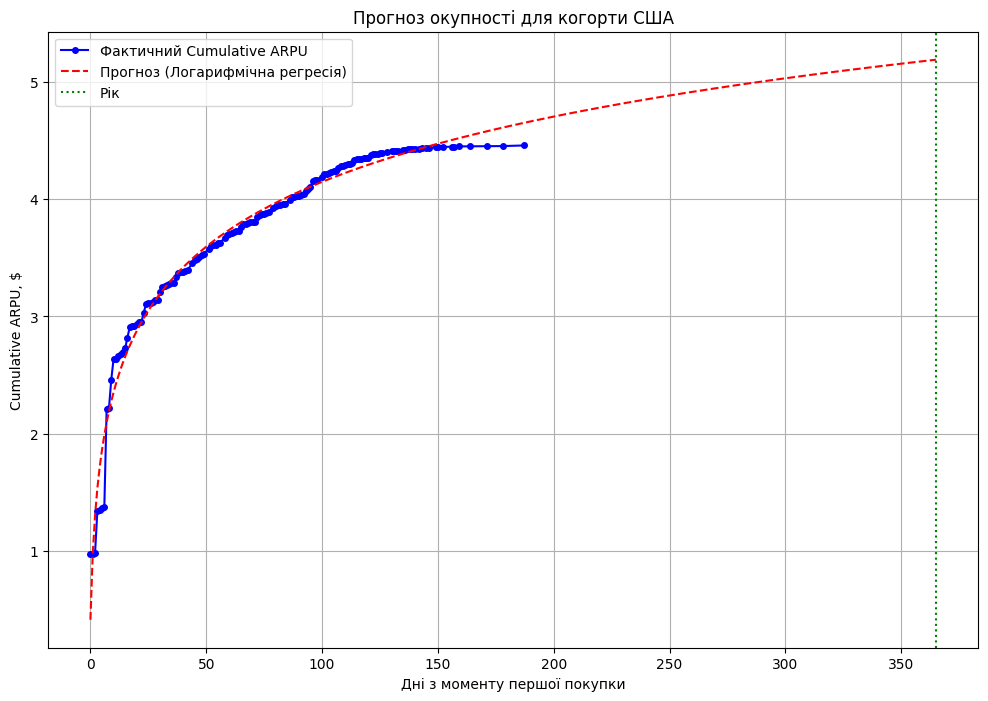

In [77]:
x_pred = np.arange(1, 367)
y_pred = log_func(x_pred, a, b)

plt.figure(figsize=(12, 8))
plt.plot(x_data, y_data, 'bo-', label='Фактичний Cumulative ARPU', markersize=4)
plt.plot(x_pred - 1, y_pred, 'r--', label='Прогноз (Логарифмічна регресія)')

plt.axvline(x=365, color='green', linestyle=':', label='Рік')
plt.title("Прогноз окупності для когорти США")
plt.xlabel("Дні з моменту першої покупки")
plt.ylabel("Cumulative ARPU, $")
plt.legend()
plt.grid(True)
plt.show()

Ми знаємо, що наше відхилення склало 3.11% при передбаченому значенні  \$5.56. Щоб врахувати відхилення, будемо орієнтуватись на нижню межу, що складе **\$5.56 - \$0.17 = \$5.39**. Це і буде максимальна сума, яку можна витратити на користувача, аби не отримати збитків. Відповідно, все, що менше за це, принесе нам прибуток

## Підготовка датасету до роботи з Tableau

In [78]:
tier_1 = ['US', 'GB', 'CA', 'AU']
tier_2 = ['DE', 'FR', 'IT', 'ES', 'JP', 'KR', 'NL', 'SE', 'CH', 'NO']

def get_tier(country_code):
    if country_code in tier_1:
        return 'Tier 1'
    elif country_code in tier_2:
        return 'Tier 2'
    elif pd.isna(country_code) or country_code == 'Unknown':
        return 'Unknown'
    else:
        return 'Tier 3'

df['Tier'] = df['country'].apply(get_tier)
df['Tier'].value_counts()

,count
Tier,
Tier 3,14334
Tier 1,6992
Tier 2,4168
Unknown,4


In [79]:
columns_for_dashboard = [
    'rc_original_app_user_id', 'start_time', 'refunded_at',
    'purchase_price_in_usd', 'net_revenue_usd',
    'subscription_type', 'country', 'Tier'
]

# df[columns_for_dashboard].to_csv('/content/drive/MyDrive/JustTechTest/dashboard_data_final.csv', index=False)
# files.download('dashboard_data_final.csv')

# Executive Summary

Під час проведеного аналізу платіжних даних було розраховано ключові продуктово-фінансові метрики. Нижче наведено основні результати:

### 1. Загальні показники монетизації
* **ARPU:** 3.39 USD
* **ARPPU:** 7.72 USD
* **Net Revenue з когорти лютого 2025 року (Feb'25):** 10,051.70 USD

### 2. Динаміка середнього доходу за типами підписок (ARPU)

| Тип підписки | ARPU за 30 днів (USD) | ARPU за 90 днів (USD) |
| :--- | :--- | :--- |
| **Annual** | 3.90 | 4.03 |
| **Monthly** | 2.36 | 3.66 |
| **Quarterly** | 2.72 | 2.78 |
| **Weekly** | 1.36 | 2.16 |


### 3. Утримання та лояльність користувачів
* **Середня кількість оплат на користувача, що платить:** 2.83
* **Медіанна кількість оплат:** 1.0

### 4. Топ-5 країн за Net Revenue
Сполучені Штати є абсолютним лідером та найбільш прибутковим ринком для нашого продукту.

| Місце | Країна | Net Revenue (USD) |
| :---: | :--- | :--- |
| **1** | **US (США)** | **6057.65** |
| 2 | GB (Британія) | 2290.39 |
| 3 | RO (Румунія) | 2133.52 |
| 4 | PL (Польща) | 2054.39 |
| 5 | DE (Німечнниа) | 1783.84 |


### 5. Прогноз окупності на ринку США
* **Прогнозований LTV (ARPU за 1 рік):** 5.19 USD
* **Середнє абсолютне відхилення моделі (MAPE):** 2.87%

>  Щоб врахувати відхилення моделі та уникнути збитків, безпечна нижня межа LTV становить 5.05 USD (5.19 - 0.14). Відповідно, максимальна вартість залучення одного користувача зі США **не повинна перевищувати 5.05 USD** .

---

### Короткий підсумок
Економіка додатку демонструє життєздатність із сильним фокусом на ринок США, який генерує найбільшу частку чистого прибутку. Аналіз виявив дві ключові зони для росту:
1. **Покращення утримання:** Медіана кількості оплат на рівні 1.0 свідчить про значний відтік клієнтів після першого платежу. Продуктовій команді варто сфокусуватися на підвищенні цінності додатку в перші дні використання.
2. **Оптимізація маркетингу:** Для масштабування на ринку США компанія може безпечно купувати користувачів за ціною нижче за $5.05, знаючи, що ці інвестиції окупляться протягом одного року.



## Tableau Dashboard

Нижче знаходить прев'ю дашборда, виконаного в Tableau. Він підтримує фільтрування за когортами (по місяцях), типами підписок та тірами країн. Для повного ознайомення, будь ласка, перейдіть за [посиланням](https://public.tableau.com/views/AppSubscriptionAnalysis/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

In [80]:
dashboard_url = "https://public.tableau.com/views/AppSubscriptionAnalysis/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link?:showVizHome=no&:embed=true"
IFrame(src=dashboard_url, width=1000, height=800)